## XBRL US API - FERC 714 Part III - Schedule 2. Planning Area Hourly Demand

### Authenticate for access token 
Click in the gray code cell below, then click the Run button above to execute the cell. Type your XBRL US Web account email, account password, Client ID, and secret as noted, pressing the Enter key on the keyboard after each entry.

XBRL US limits records returned for a query to improve efficiency; this script loops to collect all data from the Public Filings Database for a query. **Non-members might not be able to return all data for a query** - join XBRL US for comprehensive access - https://xbrl.us/join.

In [ ]:
import os, re, sys, json
import requests
import pandas as pd
from IPython.display import display, HTML
import numpy as np
import getpass
from datetime import datetime
import urllib
from urllib.parse import urlencode


class tokenInfoClass:
    access_token = None
    refresh_token = None
    email = None
    username = None
    client_id = None
    client_secret = None
    url = 'https://api.xbrl.us/oauth2/token'
    headers = {"Content-Type": "application/x-www-form-urlencoded"}
	
def refresh(info):
    refresh_auth = {
                'client_id': info.client_id, 
				'client_secret' : info.client_secret, 
				'grant_type' : 'refresh_token', 
				'platform' : 'ipynb', 
				'refresh_token' : info.refresh_token 
                }
    refreshres = requests.post(info.url, data=refresh_auth, headers=info.headers)
    refresh_json = refreshres.json()
    info.access_token = refresh_json['access_token']
    info.refresh_token = refresh_json['refresh_token']
    print('Your access token(%s) is refreshed for 60 minutes. If it expires again, run this cell to generate a new token and continue to use the query cells below.' % (info.access_token))
    return info	

tokenInfo = tokenInfoClass()

tokenInfo.email = input('Enter your XBRL US Web account email: ')
tokenInfo.password = getpass.getpass(prompt='Password: ')
tokenInfo.client_id = getpass.getpass(prompt='Client ID: ')
tokenInfo.client_secret = getpass.getpass(prompt='Secret: ')

body_auth = {'username' : tokenInfo.email, 
            'client_id': tokenInfo.client_id, 
            'client_secret' : tokenInfo.client_secret, 
            'password' : tokenInfo.password, 
            'grant_type' : 'password', 
            'platform' : 'ipynb' }

#print(body_auth)

payload = urlencode(body_auth)
res = requests.request("POST", tokenInfo.url, data=payload, headers=tokenInfo.headers)
auth_json = res.json()

if 'error' in auth_json:
    print("\n\nThere was a problem generating the access token: %s.  Run the first cell again and enter the credentials." % (auth_json['error_description']))
else:
    tokenInfo.access_token = auth_json['access_token']
    tokenInfo.refresh_token = auth_json['refresh_token']
    print ("\n\nYour access token expires in 60 minutes. After it expires, it should be regenerated automatically.  If not, run the cell rerun the first query cell. \n\nFor now, skip ahead to the section 'Make a Query'.")
	
#print(vars(tokenInfo))
print('\n\naccess token: ' + tokenInfo.access_token + ' refresh token: ' + tokenInfo.refresh_token)

### Make a query 
After the access token confirmation appears above, you can modify the query below and use the **_Cell >> Run_** menu option with the cell **immediately below this text** to run the query for updated results. 

The sample results are for one concept reported hourly for two fiscal years of data by an entity filing data on Form 714 for 2022.  **To get more entities, paste the query for _a list of Form 714 filer entity codes_ (below) into a browser and login to XBRL US**, then copy value(s) as a comma-separated list into the corresponding line below.
  
Refer to XBRL API documentation at https://xbrlus.github.io/xbrl-api/#/Facts/getFactDetails for other endpoints and parameters to filter and return. 

In [ ]:
### Example Queries (these can open in a browser for quick reference)
# query taxonomies published for a specific year
# https://api.xbrl.us/api/v1/dts/search?fields=dts.id,dts.version.sort(DESC),dts.taxonomy-name.sort(DESC)&dts.version=2023

# query unique Statements in the 2023 FERC Form 714 Taxonomy
# https://api.xbrl.us/api/v1/dts/731060/network/search?network.link-name=presentationLink&fields=network.role-description.sort(ASC),dts.id&unique

# query for a list of Form 714 filer entity codes:
# https://api.xbrl.us/api/v1/report/search?report.document-type=714&fields=report.entity-name.sort(ASC),entity.code&unique


### Define the parameters for the filter and fields to be returned

# Define endpoint (common values: fact, entity, report, cube, label, concept, relationship - see https://xbrlus/github.io/xbrl-api for additional endpoint options)

endpoint = 'fact'

# Define parameters of the query

document_types = [
    '714'
    ]

concepts = [
    'PlanningAreaHourlyDemandMegawatts'
    ]

entity_codes = [
    'C000030','C000029',
    ]

report_years = [
    '2021','2022'
    ]

# Define data fields to return (multi-sort based on order)
fields = [ 
		'entity.name.sort(ASC)',
		'entity.code',
		'period.instant.sort(ASC)',
		'fact.value',
		'report.year-focus',
		'period.fiscal-year',
		'concept.local-name',
		'report.html-url'
        ]

# Combine variables above with XBRL API attributes as filters and fields 
params = { 
         'report.document-type': ','.join(document_types),
         'concept.local-name': ','.join(concepts),
         'entity.code': ','.join(entity_codes),
         'report.year-focus': ','.join(report_years),
         'fact.ultimus': 'TRUE',
         'fields': ','.join(fields)
         }

# Set unique rows as True of False (True drops any duplicate rows)
unique = True

# Limit the number of rows displayed by the notebook (does not impact the data frame)
rows_to_display = 10 # Set as '' to display all rows in the notebook


### Execute the query with loop for all results 
### THIS SECTION DOES NOT NEED TO BE EDITED

search_endpoint = 'https://api.xbrl.us/api/v1/' + endpoint + '/search'
if unique:
    search_endpoint += "?unique"
orig_fields = params['fields']
offset_value = 0
res_df = []
count = 0
query_start = datetime.now()
printed = False
run_query = True

while True:
    if not printed:
        print("On", query_start.strftime("%c"), tokenInfo.email, "(client ID:", str(tokenInfo.client_id.split('-')[0]), "...) started the query and")
        printed = True
    retry = 0
    while retry < 3:
        res = requests.get(search_endpoint, params=params, headers={'Authorization' : 'Bearer {}'.format(tokenInfo.access_token)})
        res_json = res.json()
        if 'error' in res_json:
            if res_json['error_description'] == 'Bad or expired token':
                tokenInfo = refresh(tokenInfo)
            else: 
                print('There was an error: {}'.format(res_json['error_description']))
                run_query = False
                break
        else: 
		        break
        retry +=1
        if retry >= 3:
            print("Can't refresh the access token.  Run the first query block, then rerun the query.")
            run_query = False

    if not run_query:
       break

    print("up to", str(offset_value + res_json['paging']['limit']), "records are found so far ...")

    res_df += res_json['data']

    if res_json['paging']['count'] < res_json['paging']['limit']:
        print(" - this set contained fewer than the", res_json['paging']['limit'], "possible, only", str(res_json['paging']['count']), "records.")
        break
    else: 
        offset_value += res_json['paging']['limit'] 
        if 100 == res_json['paging']['limit']:
                params['fields'] = orig_fields + ',' + endpoint + '.offset({})'.format(offset_value)
                if offset_value == 10 * res_json['paging']['limit']:
                        break 
        elif 500 == res_json['paging']['limit']:
                params['fields'] = orig_fields + ',' + endpoint + '.offset({})'.format(offset_value)
                if offset_value == 4 * res_json['paging']['limit']:
                        break 
        params['fields'] = orig_fields + ',' + endpoint + '.offset({})'.format(offset_value)

if not 'error' in res_json:
    current_datetime = datetime.now().replace(microsecond=0)
    time_taken = current_datetime - query_start
    index = pd.DataFrame(res_df).index
    total_rows = len(index)
    your_limit = res_json['paging']['limit']
    limit_message = "If the results below match the limit noted above, you might not be seeing all rows, and should consider upgrading (https://xbrl.us/access-token).\n"
    
    if your_limit == 100:
        print("\nThis non-Member account has a limit of " , 10 * your_limit, " rows per query from our Public Filings Database. " + limit_message)
    elif your_limit == 500:
        print("\nThis Basic Individual Member account has a limit of ", 4 * your_limit, " rows per query from our Public Filings Database. " + limit_message)
    
    print("\nAt " + current_datetime.strftime("%c") +  ", the query finished with  ", str(total_rows), "  rows returned in " + str(time_taken) + " for \n" +  urllib.parse.unquote(res.url))
    
    df = pd.DataFrame(res_df)
    # the format truncates the HTML display of numerical values to two decimals; .csv data is unaffected
    pd.options.display.float_format = '{:,.2f}'.format
    display(HTML(df.to_html(max_rows=rows_to_display)))

    # set period.instant as datetimeindex for resampling
    df['period.instant'] = pd.to_datetime(df['period.instant'], format='%Y-%m-%d %H:%M:%S')
    df = df.set_index('period.instant')
    df.index = pd.to_datetime(df.index)

On Mon Nov 18 15:37:43 2024 info@xbrl.us (client ID: 69e1257c ...) started the query and
up to 5000 records are found so far ...
up to 10000 records are found so far ...
up to 15000 records are found so far ...
up to 20000 records are found so far ...
up to 25000 records are found so far ...
up to 30000 records are found so far ...
up to 35000 records are found so far ...
up to 40000 records are found so far ...
 - this set contained fewer than the 5000 possible, only 38 records.

At Mon Nov 18 15:37:50 2024, the query finished with   35038   rows returned in 0:00:06.730763 for 
https://api.xbrl.us/api/v1/fact/search?unique&report.document-type=714&concept.local-name=PlanningAreaHourlyDemandMegawatts&entity.code=C000030,C000029&report.year-focus=2021,2022&fact.ultimus=TRUE&fields=entity.name.sort(ASC),entity.code,period.instant.sort(ASC),fact.value,report.year-focus,period.fiscal-year,concept.local-name,report.html-url,fact.offset(35000)


,entity.name,entity.code,period.instant,fact.value,report.year-focus,period.fiscal-year,concept.local-name,report.html-url
0,ISO New England Inc.,C000029,2021-01-01 01:00:00,"12,192.00",2021,2020,PlanningAreaHourlyDemandMegawatts,https://ecollection.ferc.gov/api/DownloadDocument/148344/3?filename=XBRL_4_48_20220601073855_92735.html
1,ISO New England Inc.,C000029,2021-01-01 02:00:00,"11,740.00",2021,2020,PlanningAreaHourlyDemandMegawatts,https://ecollection.ferc.gov/api/DownloadDocument/148344/3?filename=XBRL_4_48_20220601073855_92735.html
2,ISO New England Inc.,C000029,2021-01-01 03:00:00,"11,476.00",2021,2020,PlanningAreaHourlyDemandMegawatts,https://ecollection.ferc.gov/api/DownloadDocument/148344/3?filename=XBRL_4_48_20220601073855_92735.html
3,ISO New England Inc.,C000029,2021-01-01 04:00:00,"11,399.00",2021,2020,PlanningAreaHourlyDemandMegawatts,https://ecollection.ferc.gov/api/DownloadDocument/148344/3?filename=XBRL_4_48_20220601073855_92735.html
4,ISO New England Inc.,C000029,2021-01-01 05:00:00,"11,508.00",2021,2020,PlanningAreaHourlyDemandMegawatts,https://ecollection.ferc.gov/api/DownloadDocument/148344/3?filename=XBRL_4_48_20220601073855_92735.html
...,...,...,...,...,...,...,...,...
35033,"PJM Interconnection, LLC",C000030,2022-12-31 20:00:00,"85,172.38",2022,2022,PlanningAreaHourlyDemandMegawatts,https://ecollection.ferc.gov/api/DownloadDocument/180486/3?filename=XBRL_4_83_20230612090954_112777.html
35034,"PJM Interconnection, LLC",C000030,2022-12-31 21:00:00,"82,952.54",2022,2022,PlanningAreaHourlyDemandMegawatts,https://ecollection.ferc.gov/api/DownloadDocument/180486/3?filename=XBRL_4_83_20230612090954_112777.html
35035,"PJM Interconnection, LLC",C000030,2022-12-31 22:00:00,"80,383.59",2022,2022,PlanningAreaHourlyDemandMegawatts,https://ecollection.ferc.gov/api/DownloadDocument/180486/3?filename=XBRL_4_83_20230612090954_112777.html
35036,"PJM Interconnection, LLC",C000030,2022-12-31 23:00:00,"77,960.75",2022,2022,PlanningAreaHourlyDemandMegawatts,https://ecollection.ferc.gov/api/DownloadDocument/180486/3?filename=XBRL_4_83_20230612090954_112777.html


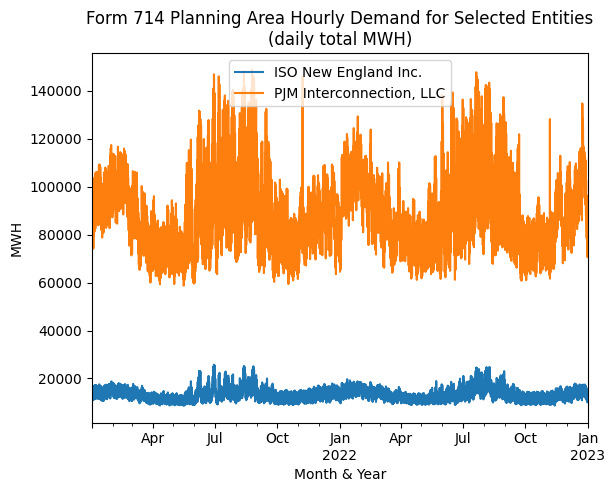

In [ ]:
#group data by entity and display MWH as line chart
grouped = df.groupby('entity.name')['fact.value'].plot(legend=True, 
                                             xlabel = "Month & Year", 
                                             ylabel="MWH", 
                                             title="Form 714 Planning Area Hourly Demand for Selected Entities\n(daily total MWH)")

In [ ]:
# If you run this program locally, you can save the output to a file on your computer (modify D:\results.csv to your system)
df.to_csv(r"D:\results.csv",sep=",")

# Google Colab users - comment out the line above and uncomment the code below to save the data frame as a .csv in your Google Drive

#from google.colab import drive
#drive.mount('drive')
#df.to_csv('data.csv')
#!cp data.csv "drive/My Drive/"